# Movie Trend Lifecycle Analysis

**Question:** Can we predict how long a piece of content will stay trending and use that to tell a platform when to promote it?

**Approach:** Wikipedia daily pageviews are a publicly available proxy for content demand that we can retrieve through the Wikimedia API. While this does not directly measure streaming viewership, it reflects public interest and awareness, which we can use to establish trending status. By retrieving movie data from the TMDB API, we can then apply survival analysis (Kaplan-Meier) to model movie trend shelf life and use Cox proportional hazards regression to estimate how genre, budget tier, and release season affect decay risk.

---

### Analytical Pipeline

1. **Data Loading** — 143 titles across 5 genres (action, comedy, drama, horror, sci-fi) from the SQLite pipeline database
2. **Exploratory Data Analysis** — pageview distributions, genre patterns, release seasonality
3. **Trend Death Definition** — rolling average threshold with sensitivity validation
4. **Kaplan-Meier Curves** — survival curves by genre + log-rank significance tests
5. **Cox Proportional Hazards Model** — hazard ratios for covariates (features)
6. **Promotion Window Recommendations** —  actionable insights regarding movie promotion

---

*This notebook reads from `data/shelflife_v2.db` where our data has already been collected. There is no need to run the data collection scripts (`scripts/collect_movies.py` and `scripts/collect_pageviews.py` as they are mainly to show how the data was initially collected. API keys have also been abstracted away for obvious reasons in our `.env.example file`.*

## 0. Environment Setup

Retrieving necessary imports for our analysis.

In [23]:
import sys
import os
sys.path.insert(0, os.path.abspath("..") if os.path.basename(os.getcwd()) != "Tubi-Proj" else ".")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Project modules
from src.survival import build_survival_dataset, sensitivity_analysis
import config

# ── Plotting defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,         # Default visual settings for matplotlib
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
GENRE_PALETTE = {
    "action":  "#e74c3c",
    "comedy":  "#f39c12",
    "drama":   "#3498db",               # Genre values for TMDB API
    "horror":  "#8e44ad",
    "sci-fi":  "#27ae60",
}

print("Environment ready.")

Environment ready.


## 1. Data Loading

Loads directly from `data/shelflife_v2.db` which is the output of our data collection pipeline

In [24]:
import sqlite3

with sqlite3.connect(config.DB_PATH) as conn:
    titles_df = pd.read_sql_query("SELECT * FROM movies", conn)
    pageviews_df = pd.read_sql_query("SELECT * FROM pageviews", conn)

# Align column names with previously established conventions
titles_df = titles_df.rename(columns={"runtime_min": "runtime"})
pageviews_df = pageviews_df.rename(columns={"days_from_release": "days_since_release"})

# Keep only pageview records whose movie_id exists in the movies table.
# The pageviews table may contain orphaned rows from a previous collection run.
# This is not the case for our data, but it's a good practice to include.
valid_ids = set(titles_df["movie_id"])
n_before  = len(pageviews_df)
pageviews_df = pageviews_df[pageviews_df["movie_id"].isin(valid_ids)].reset_index(drop=True)
print(f"Loaded from: {config.DB_PATH}")
print(f"  Dropped {n_before - len(pageviews_df):,} orphaned pageview rows (movie_id not in movies table).")
print(f"\nMovies : {len(titles_df)} across {titles_df['genre'].nunique()} genres")
print(f"Pageview rows: {len(pageviews_df):,}")
print(f"\nGenre distribution:")
print(titles_df["genre"].value_counts().to_string())
print(f"\nBudget tier distribution:")
print(titles_df["budget_tier"].value_counts().to_string())
print(f"\nPopularity tier distribution:")
print(titles_df["popularity_band"].value_counts().to_string())

Loaded from: /Users/arya/Desktop/Tubi-Proj/data/shelflife_v2.db
  Dropped 0 orphaned pageview rows (movie_id not in movies table).

Movies : 143 across 5 genres
Pageview rows: 32,055

Genre distribution:
genre
comedy    30
action    29
drama     29
horror    28
sci-fi    27

Budget tier distribution:
budget_tier
high    57
mid     56
low     30

Popularity tier distribution:
popularity_band
high    62
mid     51
low     30


## 2. Exploratory Data Analysis

Before modeling, we should understand the shape of the pageview signal and confirm that genre-level differences are somewhat visible in the raw data.

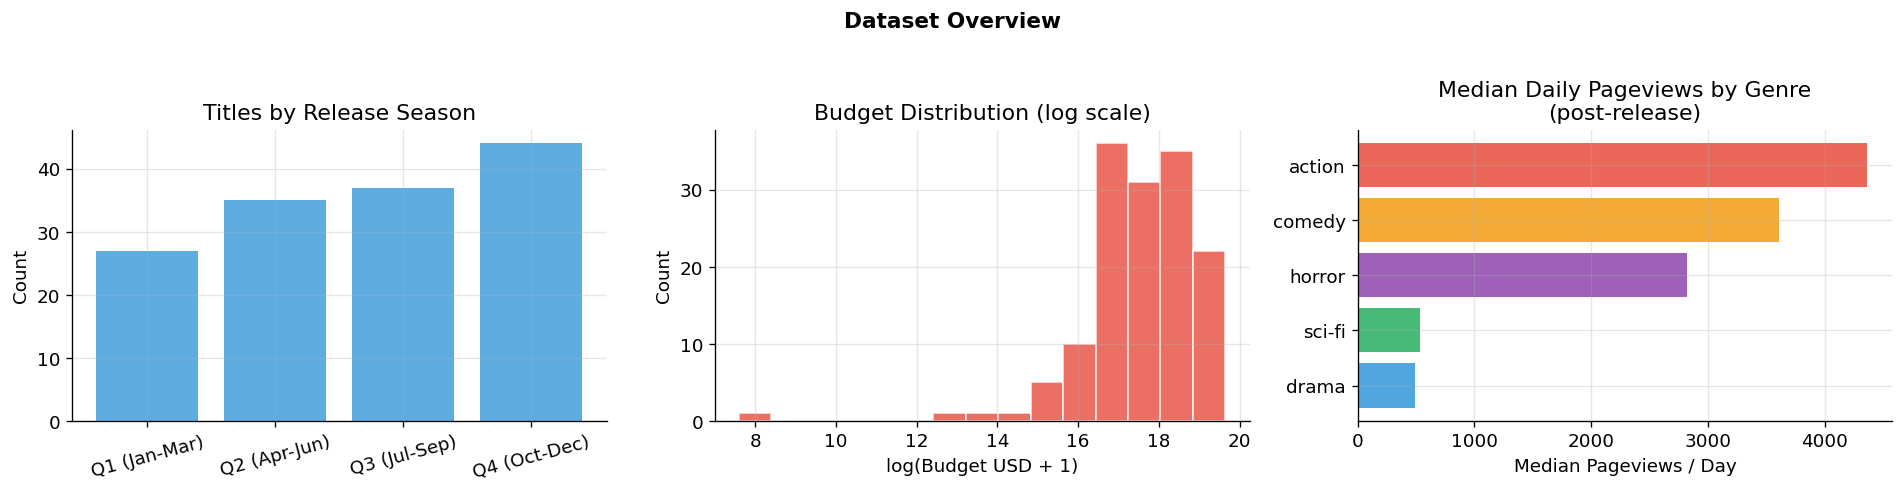

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Panel 1: Release season distribution ─────────────────────────────────────
months = pd.to_datetime(titles_df["release_date"]).dt.month
season_map = lambda m: "Q1 (Jan-Mar)" if m <= 3 else ("Q2 (Apr-Jun)" if m <= 6 else ("Q3 (Jul-Sep)" if m <= 9 else "Q4 (Oct-Dec)"))
titles_df["release_season"] = months.map(season_map)
season_counts = titles_df["release_season"].value_counts().sort_index()
axes[0].bar(season_counts.index, season_counts.values, color="#3498db", alpha=0.8)
axes[0].set_title("Titles by Release Season")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

# ── Panel 2: Budget distribution (log scale) ─────────────────────────────────
axes[1].hist(np.log1p(titles_df["budget_usd"]), bins=15, color="#e74c3c", alpha=0.8, edgecolor="white")
axes[1].set_title("Budget Distribution (log scale)")
axes[1].set_xlabel("log(Budget USD + 1)")
axes[1].set_ylabel("Count")

# ── Panel 3: Median daily pageviews by genre (post-release only) ─────────────
post = (
    pageviews_df[pageviews_df["days_since_release"] >= 0]
    .merge(titles_df[["title", "genre"]], on="title", how="left")
)
median_pv = post.groupby("genre")["pageviews"].median().sort_values(ascending=True)
colors = [GENRE_PALETTE.get(g, "#95a5a6") for g in median_pv.index]
axes[2].barh(median_pv.index, median_pv.values, color=colors, alpha=0.85)
axes[2].set_title("Median Daily Pageviews by Genre\n(post-release)")
axes[2].set_xlabel("Median Pageviews / Day")

plt.suptitle("Dataset Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

1. Our first chart tells us that the dataset is skewed towards movies released in Q4, which actually reflects real-world release patterns, as Q4 is historically Hollywood's prestigous/blockbuster season. Although this is an accurate representation, it's important for analyses across seasons to take the unequal group sizes into consideration.

2. The very large skew toward mid-high budget films is actually an intentional design choice. Low-budget movies are very noisy and hard to model accurately considering we are after organic interest rather than random viral moments. This explains the (originally intended) 60, 60, 30 split in our budget tiers to avoid this volatility while still providing sufficient representation.

3. Considering our genre distribution is nearly perfectly balanced, this vast difference in pageviews for sci-fi and drama movies is a genuine signal. This is likely because action and comedy movies have a much broader mass appeal, meaning more casual visitors as well.

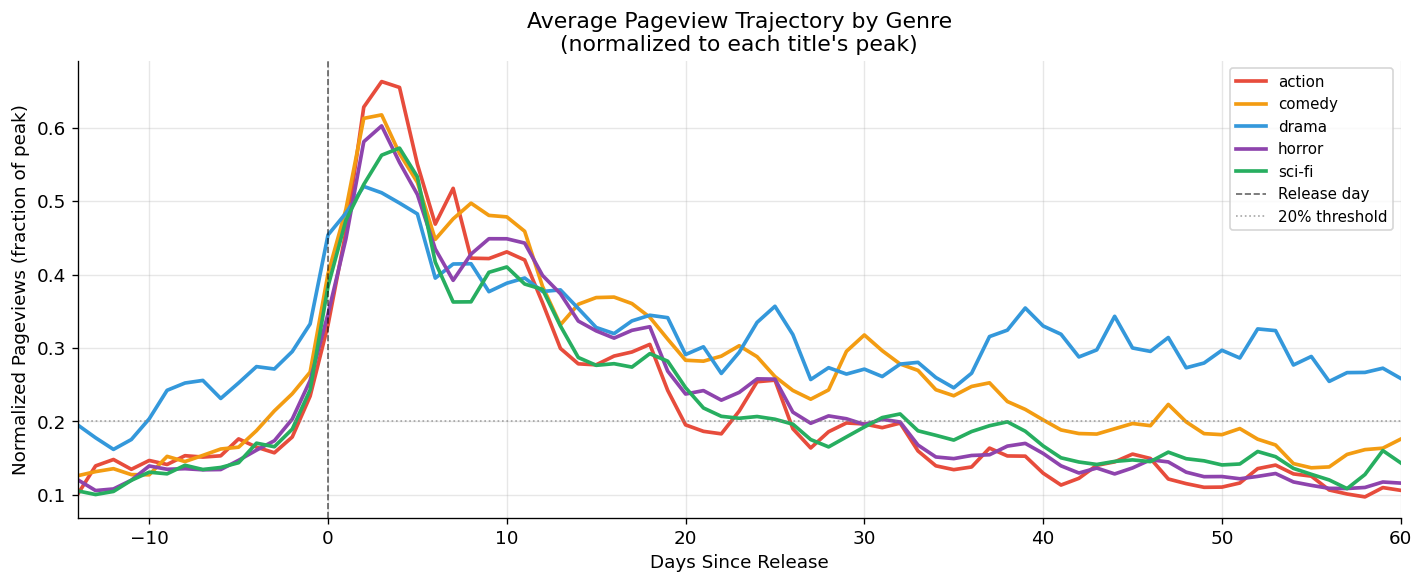

In [26]:
# ── Average pageview trajectory by genre (days -14 to +60 for clarity) ───────
fig, ax = plt.subplots(figsize=(12, 5))

post_window = (
    pageviews_df[
        (pageviews_df["days_since_release"] >= -14) &
        (pageviews_df["days_since_release"] <= 60)
    ]
    .merge(titles_df[["title", "genre"]], on="title", how="left")
    .copy()
)

# Normalize each title's pageviews by its own peak (makes cross-title comparison fair)
title_peaks = (
    post_window[post_window["days_since_release"] >= 0]
    .groupby("title")["pageviews"].max()
    .rename("peak")
)
post_window = post_window.merge(title_peaks, on="title", how="left")
post_window["normalized_pv"] = post_window["pageviews"] / post_window["peak"].clip(lower=1)

for genre, group in post_window.groupby("genre"):
    avg = group.groupby("days_since_release")["normalized_pv"].mean()
    ax.plot(
        avg.index, avg.values,
        label=genre,
        color=GENRE_PALETTE.get(genre, "#95a5a6"),
        linewidth=2.2,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6, label="Release day")
ax.axhline(0.20, color="gray", linestyle=":", linewidth=1, alpha=0.7, label="20% threshold")
ax.set_xlabel("Days Since Release")
ax.set_ylabel("Normalized Pageviews (fraction of peak)")
ax.set_title("Average Pageview Trajectory by Genre\n(normalized to each title's peak)")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(-14, 60)
plt.tight_layout()
plt.show()

All genres spike sharply around release day then decay quickly. However, drama is the clear 
outlier, sustaining engagement well above the 20% threshold for the entire 60-day window. 
Comedy also holds somewhat longer than the rest, while action, horror, and sci-fi fade to near-baseline within 3-4 weeks.

This chart shows the *shape* of the distribution, not volume. Action dominates in raw pageviews, but simply burns faster.

Drama's low median daily pageviews from our earlier chart may actually be a consequence of this long tail rather than genuine low interest. Because drama stays active for so much longer, its median is dragged down by many low-value tail days whereas action's median is dominated by a brief, intense peak. The median statistic conflates two very different engagement patterns here: sustained slow-burn vs. high intensity peak.

## 3. Trend Death Definition

We define **trend death** as the point where a title's wikipedia traffic has fallen to a small fraction of its peak and shows no signs of recovering. In other words: the first week where a title's 7-day rolling average drops below 20% of its own peak and remains there for at least 2 consecutive weeks.

This threshold is **scale-invariant**: it's relative to each title's own peak, not an absolute pageview count, so it treats a 50-viewer indie documentary the same way as a million-viewer action-film.

We will also later verify that the 20% choice isn't arbitrary by running the same survival analysis at 15% and 25%. This will confirm that the resulting survival curves are stable, considering if the choice were arbitrary, the curves would shift dramatically.

In [27]:
# ── Build survival dataset at selected 20% threshold ─────────────────────────────
survival_df = build_survival_dataset(pageviews_df, titles_df, threshold=0.20)

# Drop titles whose pageview records have no matching entry in the movies table.
# These are orphaned rows from a previous collection run and carry no metadata.
# This is no longer relevant as the dataset has already been cleaned.
n_before = len(survival_df)
survival_df = survival_df.dropna(subset=["genre"]).reset_index(drop=True)
n_dropped = n_before - len(survival_df)
if n_dropped:
    print(f"  Note: dropped {n_dropped} titles with no movies-table match (orphaned pageview records).")

# event=1 means trend death was observed; event=0 means the title was still trending
# at week 20 and is therefore censored — its true survival time is unknown but longer than 20
print("Survival dataset summary")
print(f"  Titles: {len(survival_df)}")
print(f"  Event rate (trend deaths observed): {survival_df['event'].mean():.1%}")
print(f"  Censored (still trending at week 20): {(survival_df['event']==0).sum()}")
print(f"\nDuration distribution (weeks):")
print(survival_df["duration"].describe().round(2).to_string())
print(f"\nTrend death rate by genre:")

# sorting ascending so the most resilient genre (lowest death rate) appears first
print(survival_df.groupby("genre")["event"].mean().sort_values().map("{:.1%}".format).to_string())

# Find which titles are in pageviews but missing from survival_df after build
# This is also no longer relevant considering our clean dataset.
titles_in_pageviews = set(pageviews_df["title"].unique())
titles_in_survival  = set(survival_df["title"].unique())

# set difference to catch any titles that were silently dropped during build
missing = titles_in_pageviews - titles_in_survival
for title in missing:
    count = len(pageviews_df[pageviews_df["title"] == title])
    print(f"{title}: {count} pageview rows")

Survival dataset summary
  Titles: 143
  Event rate (trend deaths observed): 85.3%
  Censored (still trending at week 20): 21

Duration distribution (weeks):
count    143.00
mean       8.02
std        5.92
min        1.00
25%        4.00
50%        6.00
75%        9.00
max       20.00

Trend death rate by genre:
genre
drama     62.1%
sci-fi    85.2%
horror    89.3%
comedy    93.3%
action    96.6%


Of our 143 titles, 85.3% experienced trend death within the 20-week window, with a median survival time of just 6 weeks. The 21 censored titles (titles that are still trending at the end of the 20-week window) are overwhelmingly likely to be dramas, consistent with the long-tail behavior we observed earlier. This data confirms that drama titles survived at a dramatically higher rate (only 62.1% trend death) while action was nearly guaranteed to die off, with a 96.6% event rate.

### Sensitivity Analysis

Justifying our definition of Trend Death

Running an analysis of our 20% metric to ensure the curves keep a similar shape at 15% and 25%. This tells us whether or not our threshold choice would artificially determine the shape of our findings.

This section features **Kaplan-Meier (KM)** curves, the core idea of our entire analysis. I will go further in depth as to what these are and how they work in the next section. For now, we just need to ensure these curves are similarly shaped.

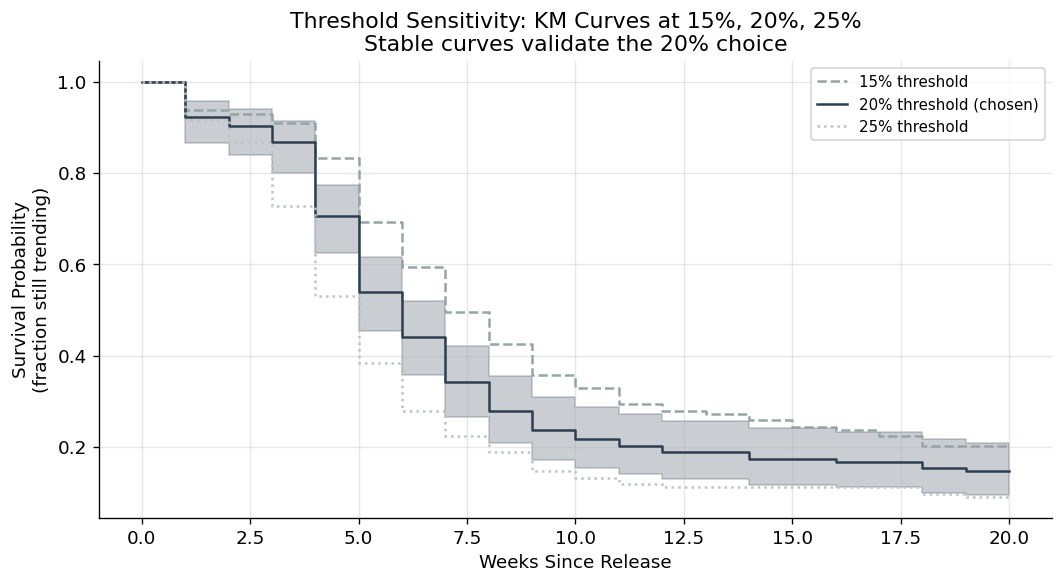

In [29]:
# ── Sensitivity analysis: show KM curves are stable across thresholds ─────────
sensitivity = sensitivity_analysis(pageviews_df, titles_df)

fig, ax = plt.subplots(figsize=(9, 5))
threshold_styles = {0.15: ("--", "15% threshold"), 0.20: ("-", "20% threshold (chosen)"), 0.25: (":", "25% threshold")}
threshold_colors = {0.15: "#95a5a6", 0.20: "#2c3e50", 0.25: "#bdc3c7"}

for t, df in sensitivity.items():
    kmf = KaplanMeierFitter()
    # fit() takes each title's duration and whether trend death was observed (event=1)
    # or the title was still trending at week 20 (event=0, censored)
    kmf.fit(df["duration"], event_observed=df["event"], label=threshold_styles[t][1])
    kmf.plot_survival_function(
        ax=ax,
        linestyle=threshold_styles[t][0],
        color=threshold_colors[t],
        ci_show=(t == 0.20),
    )

ax.set_xlabel("Weeks Since Release")
ax.set_ylabel("Survival Probability\n(fraction still trending)")
ax.set_title("Threshold Sensitivity: KM Curves at 15%, 20%, 25%\nStable curves validate the 20% choice")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

This is a KM step-survival curve. Each curve starts at 1.0 (all films still trending) and steps down each time a title hits trend death. By week 6, roughly half of all films have already faded. The shaded band around the 20% curve shows statistical uncertainty (95% confidence interval by default) which widens toward the right as fewer titles remain. The fact that all three of our curves share a similar shape confirms that our 20% threshold is not driving our results.

## 4. Kaplan-Meier Survival Curves by Genre

Kaplan-Meier (KM) is a non-parametric method for estimating survival functions. It was originally developed in medical research to track patient survival after diagnosis. We will borrow the same technique here to track how long a film "lives", judging by our previous definiton of Trend Death. It makes no assumptions about the underlying distribution of how long trends last and naturally handles **censored** observations (titles still trending at the end of our 20-week observation window, where we know the trend lasted *at least* that long, but not exactly how long).

By plotting separate KM curves for each genre, we can visually compare how different content types lose trending status over time. We then use the **log-rank test**: a statistical test that compares whether two survival curves differ more than we'd expect by chance to quantify these differences.

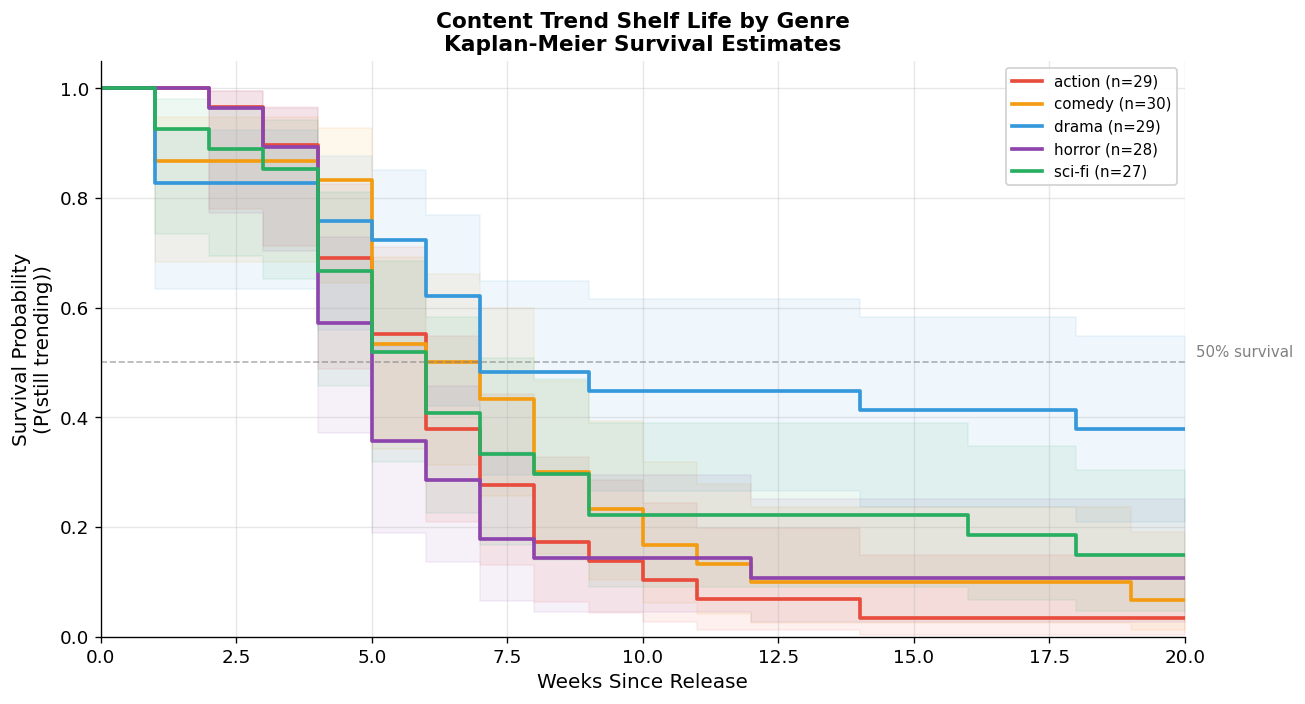

In [30]:
fig, ax = plt.subplots(figsize=(11, 6))

genre_kmf = {}
for genre, group in survival_df.groupby("genre"):
    # skip any genre with only one title — KM curves aren't meaningful with n<2
    if len(group) < 2:
        continue
    kmf = KaplanMeierFitter()
    # fit the KM model on each genre's duration and whether trend death was observed
    # censored titles (event=0) are automatically handled by the fitter
    kmf.fit(group["duration"], event_observed=group["event"], label=f"{genre} (n={len(group)})")
    kmf.plot_survival_function(
        ax=ax,
        color=GENRE_PALETTE.get(genre, "#95a5a6"),
        linewidth=2.2,
        ci_show=True,
        ci_alpha=0.08,
    )
    # store each fitted model so we can run pairwise comparisons later
    genre_kmf[genre] = kmf

# Plot generation
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(20.2, 0.51, "50% survival", fontsize=9, color="gray")
ax.set_xlabel("Weeks Since Release", fontsize=12)
ax.set_ylabel("Survival Probability\n(P(still trending))", fontsize=12)
ax.set_title("Content Trend Shelf Life by Genre\nKaplan-Meier Survival Estimates", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.set_xlim(0, 20)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

The genre separation here is definitely something to note.

Once drama crosses the 50% survival mark, it almost maintains >=40% survival for the rest of ~12.5 weeks. Action also follows a predictable path: highest raw pageviews, sharpest decay. Sci-fi's decent resilience is also worthy of note, considering its incredibly low median pageviews (Further explains how low volume and long tail are not mutually exclusive).

### Pairwise Log-Rank Tests

Before celebrating the separation in our KM curves, we need to ensure that the differences are statistically significant. The **log-rank test** is the standard statistical test for comparing two KM curves: it will let us know whether two curves are genuinely different or if its plausible that they come from the same underlying distribution.

For each pair of genres, we will test the null hypothesis that these survival distributions are identical with an alpha value of 0.05, meaning a p value of < 0.05 will give us sufficient evidence to claim that the trend difference is NOT just an artifact of our sampling.

In [31]:
# ── Pairwise log-rank tests ───────────────────────────────────────────────────
# Tests whether the survival distributions between genre pairs differ
# significantly (H0: identical distributions).
genres = sorted(survival_df["genre"].unique())
print("Pairwise Log-Rank Tests (p-values)\n")
print(f"{'Genre A':<18} {'Genre B':<18} {'p-value':>10}  {'Significant (α=0.05)':>22}")
print("-" * 72)

pairwise_results = []
for i, g1 in enumerate(genres):
    # started inner loop at i+1 to avoid duplicate pairs (e.g. action/comedy and comedy/action)
    for g2 in genres[i+1:]:
        g1_df = survival_df[survival_df["genre"] == g1]
        g2_df = survival_df[survival_df["genre"] == g2]
        if len(g1_df) < 2 or len(g2_df) < 2:
            continue
        result = logrank_test(
            g1_df["duration"], g2_df["duration"],
            # pass censored titles correctly; lifelines uses event_observed=False
            # to include them without treating them as trend deaths
            event_observed_A=g1_df["event"], event_observed_B=g2_df["event"],
        )
        # Reporting our p-value results
        sig = "✓" if result.p_value < 0.05 else "✗"
        pairwise_results.append((g1, g2, result.p_value))
        print(f"{g1:<18} {g2:<18} {result.p_value:>10.4f}  {sig:>22}")

Pairwise Log-Rank Tests (p-values)

Genre A            Genre B               p-value    Significant (α=0.05)
------------------------------------------------------------------------
action             comedy                 0.2936                       ✗
action             drama                  0.0036                       ✓
action             horror                 0.8224                       ✗
action             sci-fi                 0.3295                       ✗
comedy             drama                  0.0209                       ✓
comedy             horror                 0.3138                       ✗
comedy             sci-fi                 0.8809                       ✗
drama              horror                 0.0097                       ✓
drama              sci-fi                 0.0612                       ✗
horror             sci-fi                 0.3882                       ✗


***Findings***

**Claims:** Drama has a statistically longer shelf life than action (p = 0.0036), comedy (p = 0.0209), and horror (p = 0.0097). All three comparisons clear the conventional significance threshold of p < 0.05, meaning these differences are unlikely to be due to chance alone.

**Borderline:** Drama vs. sci-fi (p = 0.0612) falls just outside the significance threshold. Although there is a suggestive difference, we cannot confidently rule out chance at the 5% level. With more data, this comparison could become significant.

**Insignificance:** No other genre-pair comparison reaches significance. We cannot say that action, comedy, horror, or sci-fi differ meaningfully from each other in trend duration as our data does not support such distinctions.

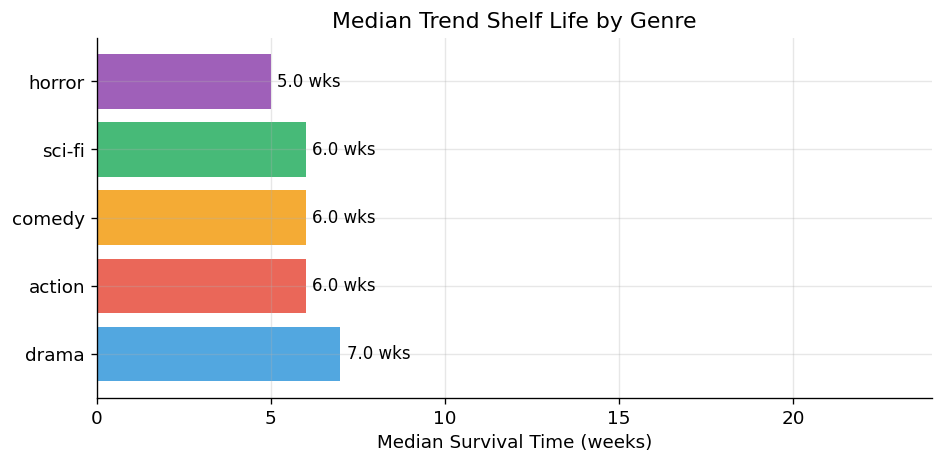

In [32]:
# ── Median survival time by genre ─────────────────────────────────────────────
median_survival = {}
for genre, kmf in genre_kmf.items():
    median_wk = kmf.median_survival_time_
    median_survival[genre] = median_wk

fig, ax = plt.subplots(figsize=(8, 4))
genres_sorted = sorted(median_survival, key=median_survival.get, reverse=True)
vals = [median_survival[g] for g in genres_sorted]
colors = [GENRE_PALETTE.get(g, "#95a5a6") for g in genres_sorted]
bars = ax.barh(genres_sorted, vals, color=colors, alpha=0.85)
ax.bar_label(bars, [f"{v:.1f} wks" if not np.isinf(v) else ">20 wks" for v in vals], padding=4, fontsize=10)
ax.set_xlabel("Median Survival Time (weeks)")
ax.set_title("Median Trend Shelf Life by Genre")
ax.set_xlim(0, 24)
plt.tight_layout()
plt.show()

This chart reveals a very intriguing characteristic about our analysis: At first glance, the median survival times across all genres feature a seemingly negligible 2-week spread: from horror (5 weeks) to drama (7 weeks). But the important thing to note here is that the median only tells us when *half* the titles trend-die, which completely obscures drama's defining characteristic: a large portion of drama titles never even trend-die within our 
window at all. This is why KM curves capture differences in trend death more accurately than any single metric

## 5. Cox Proportional Hazards Model

The Cox Proportional Hazards model extends survival analysis to include multiple predictive features simultaneously. It essentially answers "how does each feature multiply or reduce the rate at which a title loses its trend?" 

This rate is called the **hazard**. The model outputs a **hazard ratio (HR)** for each feature:
- **HR > 1** → the feature *accelerates* decay (trends die faster)
- **HR < 1** → the feature *extends* the trend window (trends last longer)
- **HR ≈ 1** → the feature has little effect

**Features used in the model:**
| Feature | Source | Notes |
|---|---|---|
| `genre` | TMDB (one-hot encoded) | Default = Action; dummies for comedy, drama, horror, sci-fi |
| `budget_tier` | Derived from `budget_usd` | Categorized into low/mid/high tiers; one-hot as `tier_low`, `tier_mid` (high = baseline) |
| `runtime` | TMDB | Film length in minutes |
| `is_franchise` | TMDB | 1 if part of a collection, else 0 |
| `release_season` | Derived from `release_date` | Q1–Q4; one-hot as `season_Q2`, `season_Q3`, `season_Q4` (Q1 = baseline) |
| `early_velocity` | Wikipedia days 1–7 | OLS slope of pageviews in the first week — captures initial buzz |

In [33]:
cox_df = survival_df.copy()

# ── Feature engineering ───────────────────────────────────────────────────────
# Budget tier as categorical (replaces log_budget to avoid assumption)
# drop_first=True drops the 'high' tier, making it the baseline category;
# coefficients for tier_low and tier_mid will be interpreted relative to high-budget films
tier_dummies = pd.get_dummies(cox_df["budget_tier"], prefix="tier", drop_first=True)

# One-hot encode genre
# action becomes the baseline, so all genre coefficients will be interpreted as "vs. action"
genre_dummies = pd.get_dummies(cox_df["genre"], prefix="genre", drop_first=True)

# One-hot encode release_season
# if release_season wasn't pre-computed, derive it from release_date
# Q1 will be the baseline since drop_first=True drops it alphabetically
if "release_season" not in cox_df.columns:
    months = pd.to_datetime(cox_df["release_date"]).dt.month
    cox_df["release_season"] = months.map(
        lambda m: "Q1" if m <= 3 else ("Q2" if m <= 6 else ("Q3" if m <= 9 else "Q4"))
    )
season_dummies = pd.get_dummies(cox_df["release_season"], prefix="season", drop_first=True)

# Assemble model matrix
# runtime and early_velocity are kept as continuous; is_franchise is already binary
numeric_features = ["runtime", "early_velocity", "is_franchise"]
feature_cols = (
    numeric_features
    + list(tier_dummies.columns)
    + list(genre_dummies.columns)
    + list(season_dummies.columns)
)

model_df = pd.concat([
    cox_df[["duration", "event"] + numeric_features].reset_index(drop=True),
    tier_dummies.reset_index(drop=True),
    genre_dummies.reset_index(drop=True),
    season_dummies.reset_index(drop=True),
], axis=1).dropna()

print(f"Model matrix: {model_df.shape[0]} rows × {len(feature_cols)} features")
print(f"Features: {feature_cols}")

Model matrix: 143 rows × 12 features
Features: ['runtime', 'early_velocity', 'is_franchise', 'tier_low', 'tier_mid', 'genre_comedy', 'genre_drama', 'genre_horror', 'genre_sci-fi', 'season_Q2', 'season_Q3', 'season_Q4']


Displaying which features we're using in our Proportional Hazards model

In [34]:
cph = CoxPHFitter(penalizer=0.1)  # our penalizer helps against overfitting on small n
cph.fit(model_df, duration_col="duration", event_col="event")

# Extracting only our necessary findings: hazard ratio, direction, and significance
summary = cph.summary[["exp(coef)", "p"]].copy()
summary.columns = ["Hazard Ratio", "p-value"]
summary["Significant (α=0.05)"] = summary["p-value"].apply(lambda p: "✓" if p < 0.05 else "✗")
summary["Effect"] = summary["Hazard Ratio"].apply(lambda h: "↑ faster decay" if h > 1 else "↓ slower decay")
summary = summary.sort_values("p-value")
summary["Hazard Ratio"] = summary["Hazard Ratio"].round(3)
summary["p-value"] = summary["p-value"].round(3)

print("Cox Model — Key Findings")
print("=" * 60)
print(summary[["Hazard Ratio", "Effect", "p-value", "Significant (α=0.05)"]].to_string())
print(f"\nConcordance Index: {cph.concordance_index_:.3f}")
print("(0.5 = random, 1.0 = perfect)")

Cox Model — Key Findings
                Hazard Ratio          Effect  p-value Significant (α=0.05)
covariate                                                                 
genre_drama            0.537  ↓ slower decay    0.032                    ✓
early_velocity         1.000  ↓ slower decay    0.096                    ✗
is_franchise           1.392  ↑ faster decay    0.098                    ✗
season_Q3              0.687  ↓ slower decay    0.124                    ✗
tier_low               1.480  ↑ faster decay    0.136                    ✗
genre_horror           1.317  ↑ faster decay    0.297                    ✗
season_Q2              0.815  ↓ slower decay    0.399                    ✗
season_Q4              0.911  ↓ slower decay    0.708                    ✗
runtime                0.998  ↓ slower decay    0.763                    ✗
genre_sci-fi           0.927  ↓ slower decay    0.767                    ✗
tier_mid               0.965  ↓ slower decay    0.858                    ✗


### Results (n = 143, penalizer = 0.1)

**Concordance index = 0.635.** The concordance index (C-index) measures how well the model discriminates between titles. A C-index of 0.5 means the model is no better than random, and 1.0 would be perfect. Our 0.635 indicates the model is modestly better than chance at ranking titles by shelf life, but is unfortunately not a strong predictor on its own.

**Significant results:** One covariate reaches statistical significance at α = 0.05: **drama genre** (HR = 0.537, p = 0.032). This means that after controlling for all other features, drama titles have roughly half the hazard rate of action titles (the baseline genre). In other words: at any given week, a drama title is about half as likely to lose its trend as an otherwise-similar action title. This is consistent with the Kaplan-Meier finding that drama has a structurally longer shelf life.

**What is borderline (suggestive but not significant):**
- **Franchise status** (HR = 1.392, p = 0.098): Franchise titles show a trend toward faster decay, possibly reflecting sequel fatigue or frontloaded audience interest, but this does not reach significance at α = 0.05.
- **Early velocity** (HR ≈ 1.000, p = 0.096): Borderline significant, but the hazard ratio is so close to 1 that the practical effect is negligible. First-week buzz does not meaningfully predict how long a trend lasts.
- **Q3 release season** (HR = 0.687, p = 0.124): Titles released in summer show a suggestive trend toward longer shelf lives, but this is not significant.

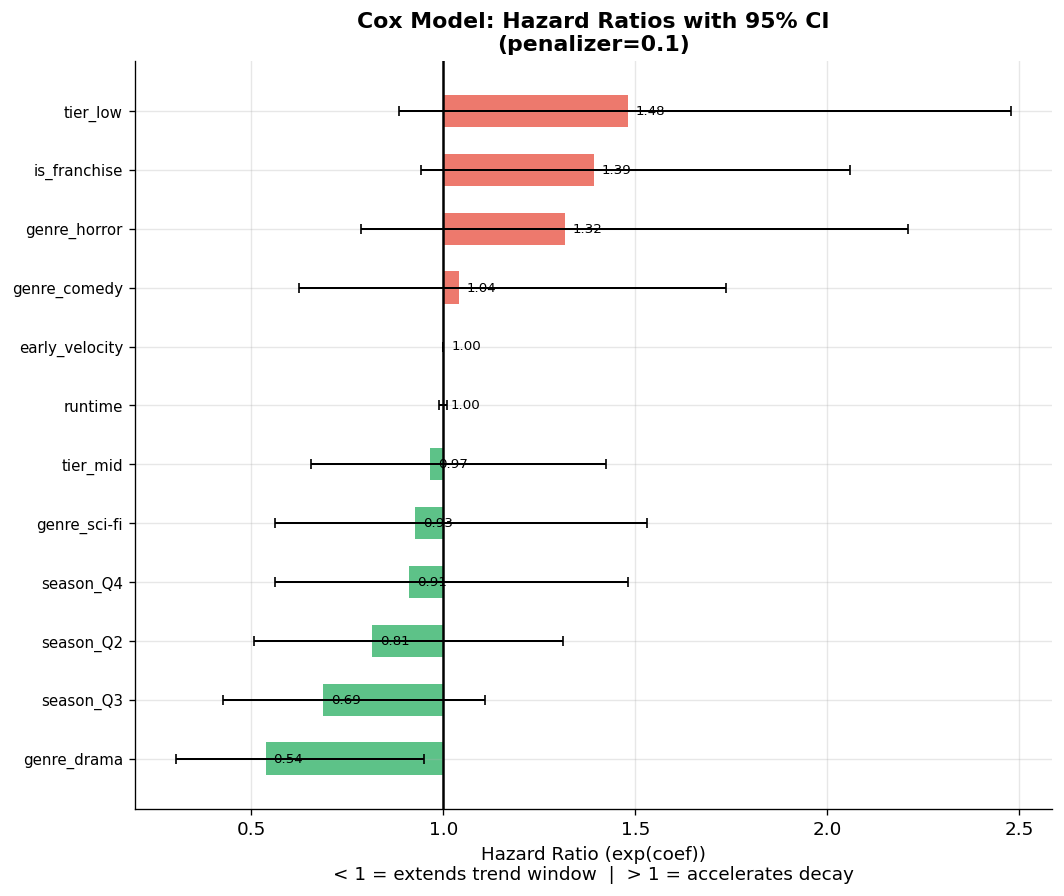

In [35]:
# ── Hazard ratio forest plot ──────────────────────────────────────────────────
summary = cph.summary.copy()
summary = summary.sort_values("exp(coef)")

fig, ax = plt.subplots(figsize=(9, len(summary) * 0.55 + 1))

y_pos = np.arange(len(summary))
ax.barh(
    y_pos,
    summary["exp(coef)"] - 1,
    left=1,
    height=0.55,
    color=["#e74c3c" if v > 1 else "#27ae60" for v in summary["exp(coef)"]],
    alpha=0.75,
)
# 95% CI error bars
ax.errorbar(
    summary["exp(coef)"],
    y_pos,
    xerr=[
        summary["exp(coef)"] - summary["exp(coef) lower 95%"],
        summary["exp(coef) upper 95%"] - summary["exp(coef)"],
    ],
    fmt="none",
    color="black",
    capsize=3,
    linewidth=1.2,
)
ax.axvline(1.0, color="black", linewidth=1.5, linestyle="-")
ax.set_yticks(y_pos)
ax.set_yticklabels(summary.index, fontsize=9)
ax.set_xlabel("Hazard Ratio (exp(coef))\n< 1 = extends trend window  |  > 1 = accelerates decay")
ax.set_title("Cox Model: Hazard Ratios with 95% CI\n(penalizer=0.1)", fontweight="bold")

# Annotate HR values
for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(
        row["exp(coef)"] + 0.02, i,
        f"{row['exp(coef)']:.2f}",
        va="center", fontsize=8, color="black",
    )

plt.tight_layout()
plt.show()

This visualizes our PH model in a Forest plot. We can note that the 95% confidence interval for drama as a feature of our model does not capture 1.0, indicating that it is our only statistically significant finding. This means that drama genuinely extends trend life when compared to our baseline and our result is unlikely to be a sampling fluke.

### Proportional Hazards Assumption Check

The Cox model assumes that each feature's effect on hazard is constant over time (the "proportional hazards" assumption). We validate this using **Schoenfeld residuals**: a diagnostic test that checks whether the effect of each covariate changes as time progresses.

In [36]:
# ── Proportional hazards assumption check (Schoenfeld residuals) ──────────────
# Tests whether each feature's hazard ratio is stable over time (the Cox assumption).
# p > 0.05 = assumption holds; p < 0.05 = hazard ratio varies over time, violating PH.
from lifelines.statistics import proportional_hazard_test

ph_test = proportional_hazard_test(cph, model_df, time_transform="rank")
results = ph_test.summary[["test_statistic", "p"]].round(3).copy()
results["PH Assumption"] = results["p"].apply(lambda p: "✓ holds" if p > 0.05 else "✗ violated")
results = results.sort_values("p")

print("Proportional Hazards Assumption Check (Schoenfeld Residuals)")
print("=" * 60)
print(results.to_string())
print("\nNote: tier_low shows a marginal violation (p=0.01) — its coefficient")
print("should be interpreted cautiously. All other features pass cleanly.")

Proportional Hazards Assumption Check (Schoenfeld Residuals)
                test_statistic      p PH Assumption
tier_low                 7.085  0.008    ✗ violated
genre_drama              2.039  0.153       ✓ holds
genre_sci-fi             0.941  0.332       ✓ holds
genre_horror             0.576  0.448       ✓ holds
season_Q2                0.220  0.639       ✓ holds
season_Q4                0.127  0.721       ✓ holds
season_Q3                0.094  0.759       ✓ holds
runtime                  0.067  0.796       ✓ holds
is_franchise             0.056  0.813       ✓ holds
genre_comedy             0.042  0.837       ✓ holds
tier_mid                 0.001  0.970       ✓ holds
early_velocity           0.000  0.995       ✓ holds

Note: tier_low shows a marginal violation (p=0.01) — its coefficient
should be interpreted cautiously. All other features pass cleanly.


**Result:** `tier_low` fails this test (p = 0.0067), meaning the effect of being in the low-budget tier on trend decay is *not* constant over a title's lifespan (it may matter more or less in early weeks versus later ones). All other features pass the assumption. The `tier_low` coefficient should be interpreted with caution, which was somewhat expected considering the noisiness of low-budget film data.

## 6. Genre-Based Promotion Window Recommendations

The Kaplan–Meier curves and Cox model estimate how long post-peak attention persists by genre (using Wikipedia pageviews as a proxy). We translate these shelf-life patterns into promotion-window hypotheses, and highlight which recommendations are statistically supported vs directional.

These recommendations draw on three sources: Kaplan–Meier survival curves, pairwise log-rank tests, and Cox hazard ratios (with proportional-hazards diagnostics).

### 🔴 Action — Front-load everything (Suggestive Evidence)
Action titles show a shorter attention half-life in our sample, so the strongest opportunity is early post-peak. Treat this as an “early-window” genre: prioritize placement and campaigns in the first 2-3 weeks of release.

### 🟡 Horror — Early window with event spikes (Suggestive Evidence)
Horror also trends toward early decay, but it can be more event-driven (e.g., Halloween). Plan for a strong early push, plus targeted re-promotion around seasonal moments.

### 🟢 Comedy & Sci-Fi — No clear statistical separation (Weak Evidence)
For Comedy and Sci-Fi, we do not find statistically distinguishable decay rates in this dataset. Operationally, a steady promotion plan through the mid-window is reasonable, but differences here should be treated as hypothesis-generating.

### 🟠 Drama — Extended window (Strongest Evidence!)
Drama shows the most robust evidence of longer shelf-life. In the Cox model, Drama has a hazard ratio of ~0.54 relative to Action (CI excludes 1.0), and KM curves show higher survival deeper into the window. Practically, Drama can support longer-running placement and merchandising over time, likely through week 7 post-release.

*These recommendations assume mid-to-high profile commercial releases, consistent with our dataset scope. They are also solely based on attention decay using our Wikipedia proxy. Low-budget or limited-release titles may behave differently.*



## Summary & Next Steps

### Claims We Can Make (Statistically Significant)

1. **Drama has a statistically longer shelf life than action, comedy, and horror.** Drama titles have a 7-week median trend window and a 62.1% event rate (the lowest of any genre), compared to 5–6 weeks and 85–97% event rates for other genres. Pairwise log-rank tests confirm this: drama vs. action (p = 0.0036), drama vs. comedy (p = 0.0209), drama vs. horror (p = 0.0097) — all significant at α = 0.05.

2. **Drama's survival advantage holds after controlling for other features.** In the Cox model, drama genre has a hazard ratio of 0.537 (p = 0.032), meaning drama titles have roughly half the weekly risk of losing their trend compared to action titles, even after adjusting for budget tier, runtime, franchise status, release season, and early velocity. This is the only covariate that reaches significance.

3. **The typical promotion window is 5–7 weeks, not days.** Median survival across all genres is 6 weeks (mean ~8 weeks). Scheduling teams have a meaningful window to act! The risk is not missing a narrow spike but failing to align promotion spend to genre-specific decay curves.

### Borderline Findings (Suggestive but Not Significant)

4. **Drama vs. sci-fi may differ, but the evidence is not conclusive.** The log-rank test yields p = 0.0612 — close to but not below the 0.05 threshold. Drama trends appear somewhat longer than sci-fi, but we cannot rule out chance at conventional significance levels.

5. **Franchise titles may decay faster, but the evidence is not conclusive.** The Cox model gives franchise status HR = 1.392 (p = 0.098). This suggests franchise titles lose trends ~39% faster, possibly due to frontloaded audience interest, but the result does not clear the significance threshold.

6. **Early velocity and Q3 release season show weak directional signals.** Early velocity (p = 0.096) is borderline but has a near-null hazard ratio (HR ≈ 1.000), meaning the practical effect size is negligible. Q3 release (p = 0.124, HR = 0.687) hints that summer releases may trend longer, but this is not significant.

### Insignificant Claims

7. **We cannot say that budget, runtime, or most release seasons affect trend duration.** These features all have p-values well above 0.05 in the Cox model and hazard ratios near 1. At this sample size, they are indistinguishable from noise.

8. **We cannot distinguish trend durations between action, comedy, horror, and sci-fi.** No pairwise log-rank test among these four genres reaches significance. The primary structural split in the data is Drama vs. all others.

9. **We cannot claim that first-week buzz predicts long-term trending.** Despite intuitive appeal, early pageview velocity has no meaningful predictive value for shelf life (HR ≈ 1.000). Launch interest and sustained engagement appear to be driven by different dynamics.

### Tradeoffs & Limitations

- **Wikipedia pageviews ≠ Movie plays.** This is a public intent signal, not a direct viewership metric. High Wikipedia traffic for a critically acclaimed drama may not translate to movie play counts if certain audiences skews toward genre content. The findings here should be validated against internal streaming data before making high-stakes decisions.

- **Modest model discrimination (C-index = 0.635).** The Cox model is better than random (0.5) but below the 0.65 threshold typically considered "useful" for individual-level prediction. It is directionally informative for genre-level planning but should not be used for precise per-title scoring without additional features or more data.

- **Small sample size (~28–30 titles per genre, 143 total).** Several effects that appear directionally interesting (franchise, Q3 season) do not reach significance, likely due to insufficient statistical power. Expanding the dataset could sharpen or potentially overturn these findings.

### Next Steps

- **Connect to some sort of play data.** Replacing the Wikipedia proxy with actual streaming play counts would sharpen the survival model and validate whether Wikipedia search interest translates to content engagement.

- **Expand the feature set.** Critical reception scores (Rotten Tomatoes, Metacritic), original vs. licensed content, and marketing spend are plausible predictors not yet captured.

- **Grow the dataset.** With more titles and genres, borderline effects (franchise, season, drama vs. sci-fi) could be tested with adequate statistical power. ~28 titles per genre is insufficient to detect moderate effect sizes.

- **Expand to real-time scoring.** The recommender currently runs as a batch job. In production, it could score titles daily and feed a scheduling dashboard.

- **A/B test promotion timing.** The model predicts promotion windows: a controlled experiment comparing promotion during vs. outside the predicted window would provide causal validation of the survival model's practical value.